# Модель предсказания дефолта по потребительскому кредиту

**Цель:** построить модель кредитного скоринга, оценивающую вероятность дефолта клиента.

**Исходные данные:** 1723 строки, 14 признаков, дисбаланс классов 11.4% дефолтов.

**Основная метрика:** PR-AUC, т.к. метрика фокусируется на целевом редком классе дефолт

**Итоговая модель:** CatBoost с Optuna-подбором гиперпараметров.

**Результат:** PR-AUC = 0.304, ROC-AUC = 0.731.

## 1. Загрузка и первичный анализ данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_excel('data.xlsx')
print('Shape:', df.shape)
print('\nТипы данных:')
print(df.dtypes)
print('\nПропуски:')
print(df.isnull().sum())
print('\nДубликаты:', df.duplicated().sum())

Shape: (1723, 14)

Типы данных:
Месяц выдачи кредита           int64
Сумма кредита                  int64
Срок кредита                   int64
Возраст клиента                int64
Пол клиента                   object
Образование клиента           object
Тип товара                    object
Наличие детей у клиента       object
Регион выдачи кредита         object
Доход клиента                  int64
Семейное положение            object
Оператор связи                object
Является ли клиентом банка    object
Флаг дефолта по кредиту       object
dtype: object

Пропуски:
Месяц выдачи кредита          0
Сумма кредита                 0
Срок кредита                  0
Возраст клиента               0
Пол клиента                   0
Образование клиента           0
Тип товара                    0
Наличие детей у клиента       0
Регион выдачи кредита         0
Доход клиента                 0
Семейное положение            0
Оператор связи                0
Является ли клиентом банка    0
Флаг дефо

**Вывод:** пропусков и дубликатов нет. В данных 1 временной признак (месяц), 4 числовых характеристики кредита/клиента, 8 категориальных признаков и целевая переменная.

## 2. EDA

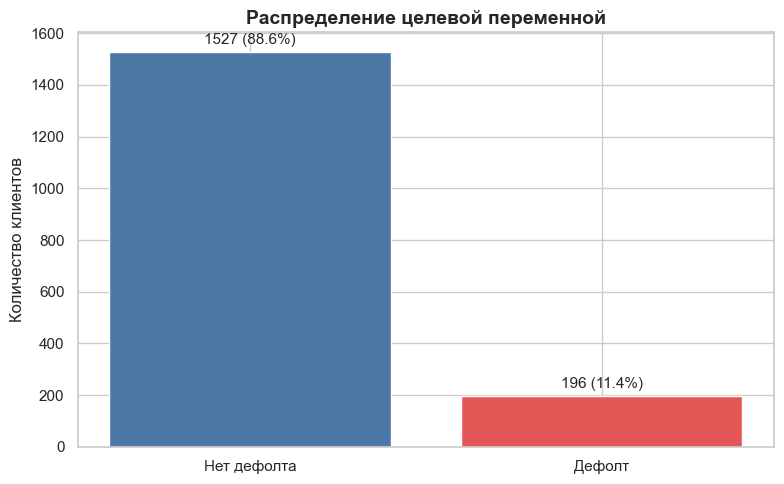

In [21]:
df['default'] = (df['Флаг дефолта по кредиту'] == 'Дефолт').astype(int)

fig, ax = plt.subplots(figsize=(8, 5))
target_counts = df['default'].value_counts().sort_index()
bars = ax.bar(['Нет дефолта', 'Дефолт'], target_counts.values, color=['#4C78A8', '#E45756'])
for bar, val in zip(bars, target_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{val} ({val/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=11)
ax.set_title('Распределение целевой переменной', fontsize=14, fontweight='bold')
ax.set_ylabel('Количество клиентов')
plt.tight_layout()
plt.show()

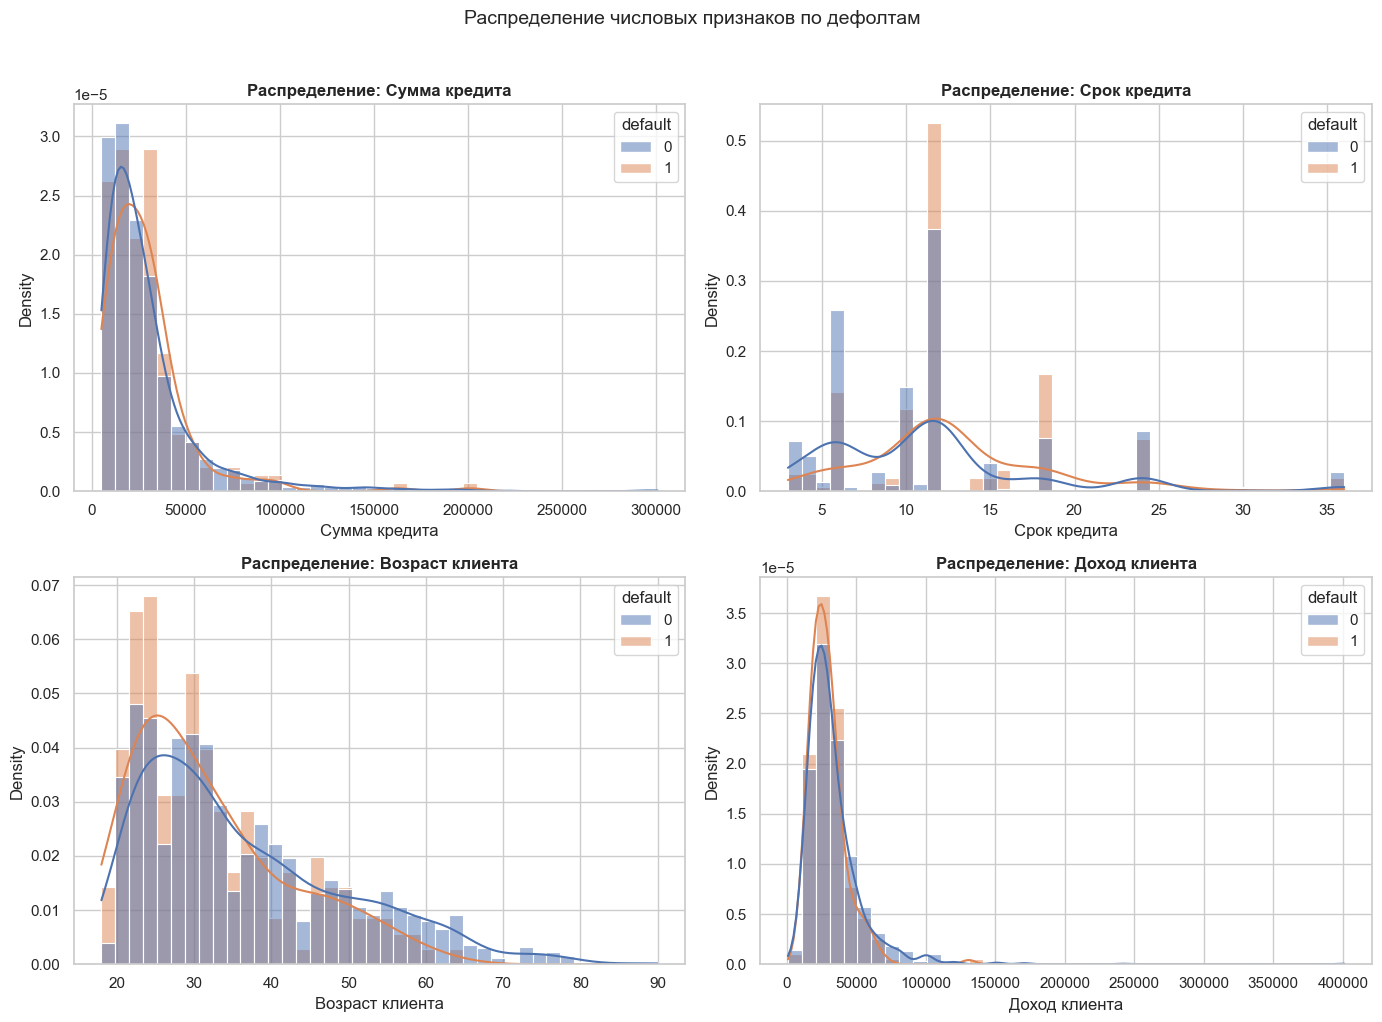

In [20]:
num_cols = ['Сумма кредита', 'Срок кредита', 'Возраст клиента', 'Доход клиента']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()
for i, col in enumerate(num_cols):
    sns.histplot(df, x=col, hue='default', bins=40, kde=True, ax=axes[i],
                  stat='density', common_norm=False)
    axes[i].set_title(f'Распределение: {col}', fontsize=12, fontweight='bold')
plt.suptitle('Распределение числовых признаков по дефолтам', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

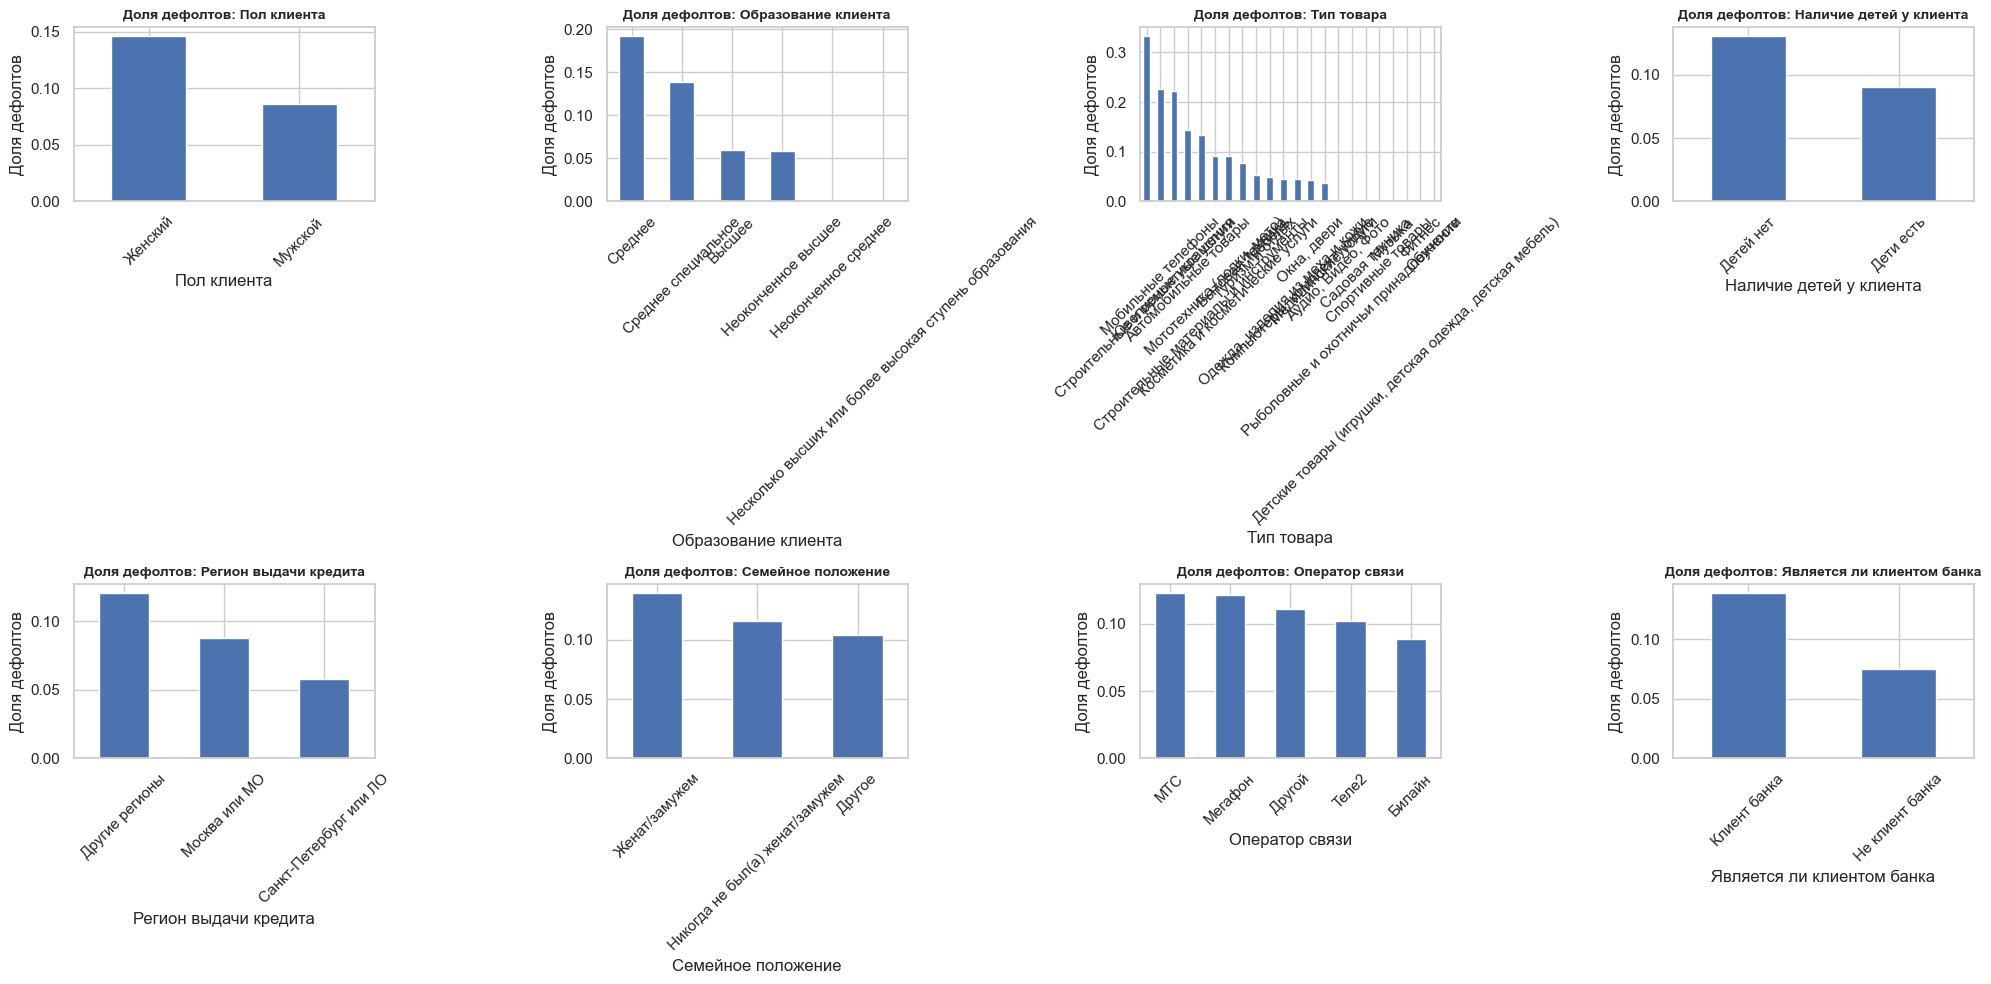

In [19]:
cat_cols = ['Пол клиента', 'Образование клиента', 'Тип товара', 'Наличие детей у клиента',
            'Регион выдачи кредита', 'Семейное положение', 'Оператор связи', 'Является ли клиентом банка']
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()
for i, col in enumerate(cat_cols):
    rate = df.groupby(col)['default'].mean().sort_values(ascending=False)
    rate.plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'Доля дефолтов: {col}', fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Доля дефолтов')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

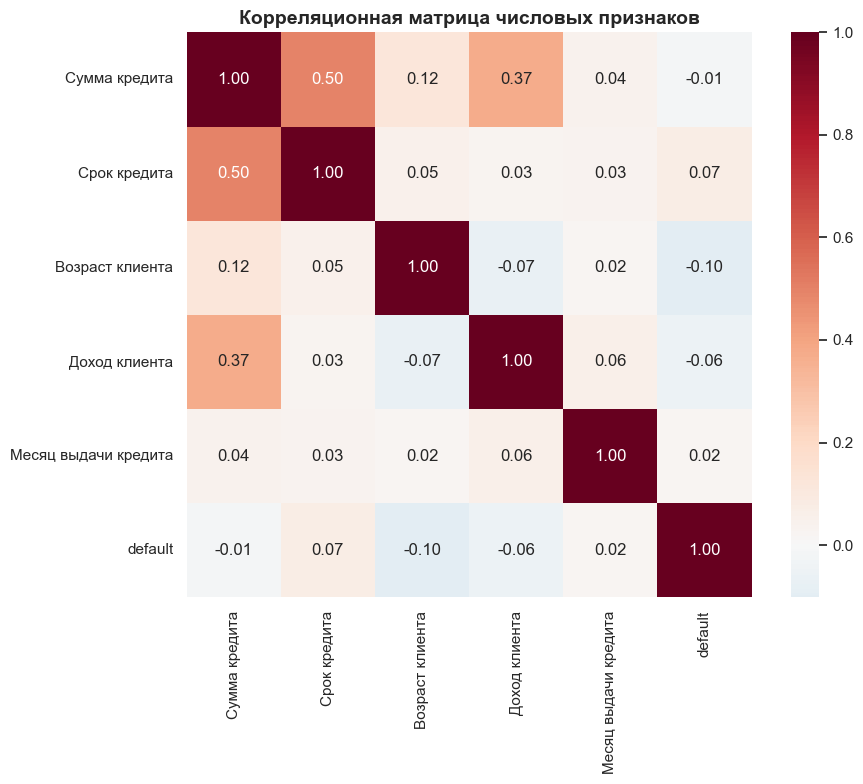

In [7]:
corr = df[num_cols + ['Месяц выдачи кредита', 'default']].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax, square=True)
ax.set_title('Корреляционная матрица числовых признаков', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Feature Engineering

Созданы новые признаки: платежи, отношения к доходу, группы риска и взаимодействия. Итого 25 числовых + 8 категориальных признаков.

In [8]:
df['monthly_payment'] = df['Сумма кредита'] / df['Срок кредита']
df['credit_to_income'] = df['Сумма кредита'] / df['Доход клиента'].replace(0, np.nan)
df['payment_to_income'] = df['monthly_payment'] / df['Доход клиента'].replace(0, np.nan)
df['income_per_age'] = df['Доход клиента'] / (df['Возраст клиента'] + 1)
df['credit_x_term'] = df['Сумма кредита'] * df['Срок кредита']

df['is_young'] = (df['Возраст клиента'] < 25).astype(int)
df['is_big_loan'] = (df['Сумма кредита'] > df['Сумма кредита'].quantile(0.75)).astype(int)
df['is_long_term'] = (df['Срок кредита'] > df['Срок кредита'].median()).astype(int)
df['is_male'] = (df['Пол клиента'] == 'Мужской').astype(int)
df['has_children'] = (df['Наличие детей у клиента'] == 'Дети есть').astype(int)
df['is_bank_client'] = (df['Является ли клиентом банка'] == 'Клиент банка').astype(int)
df['low_education'] = df['Образование клиента'].isin(['Среднее', 'Среднее специальное']).astype(int)
df['other_region'] = (df['Регион выдачи кредита'] == 'Другие регионы').astype(int)

print('Всего признаков после engineering:', df.shape[1] - 1)

Всего признаков после engineering: 27


## 4. Сравнение моделей

Были протестированы различные подходы. Ниже сравнение лучших результатов по CV PR-AUC.

In [17]:
comparison = pd.DataFrame([
    {'Модель': 'Logistic Regression (baseline)', 'PR-AUC (test)': 0.235, 'ROC-AUC': 0.719, 'Примечание': 'baseline'},
    {'Модель': 'Random Forest', 'PR-AUC (test)': 0.258, 'ROC-AUC': 0.719, 'Примечание': 'class_weight=balanced'},
    {'Модель': 'XGBoost (Optuna)', 'PR-AUC (test)': 0.303, 'ROC-AUC': 0.746, 'Примечание': 'scale_pos_weight + WOE'},
    {'Модель': 'XGBoost + SMOTE', 'PR-AUC (test)': 0.252, 'ROC-AUC': 0.710, 'Примечание': 'oversampling'},
    {'Модель': 'CatBoost (Optuna)', 'PR-AUC (test)': 0.304, 'ROC-AUC': 0.731, 'Примечание': 'финальная модель'},
])
comparison

,Модель,PR-AUC (test),ROC-AUC,Примечание
0,Logistic Regression (baseline),0.235,0.719,baseline
1,Random Forest,0.258,0.719,class_weight=balanced
2,XGBoost (Optuna),0.303,0.746,scale_pos_weight + WOE
3,XGBoost + SMOTE,0.252,0.710,oversampling
4,CatBoost (Optuna),0.304,0.731,финальная модель


**Выбор финальной модели:** CatBoost показал лучшее соотношение качества и стабильности. CV PR-AUC = 0.343, тест PR-AUC = 0.304. Модель не переобучена.

In [10]:
with open('artifacts/metrics.json', 'r', encoding='utf-8') as f:
    metrics = json.load(f)

pd.DataFrame([{'Параметр': k, 'Значение': v} for k, v in metrics['BestParams'].items()])

,Параметр,Значение
0,iterations,808.000000
1,depth,2.000000
2,learning_rate,0.017360
3,l2_leaf_reg,0.293272
4,border_count,98.000000
5,subsample,0.841033
6,scale_pos_weight,1.627994


## 6. Метрики финальной модели

In [12]:
pd.DataFrame([{'Метрика': k, 'Значение': round(v, 4) if isinstance(v, (int, float)) else v}
              for k, v in metrics.items()
              if k not in ['BestParams', 'ConfusionMatrix', 'Model', 'BusinessRules']])

,Метрика,Значение
0,PR-AUC,0.2493
1,ROC-AUC,0.7197
2,Precision,0.3404
3,Recall,0.4103
4,F1,0.3721
5,Threshold,0.3596
6,AutoRejectCount,4.0000
7,AutoRejectPct,1.1594
8,CV_PR_AUC,0.3425


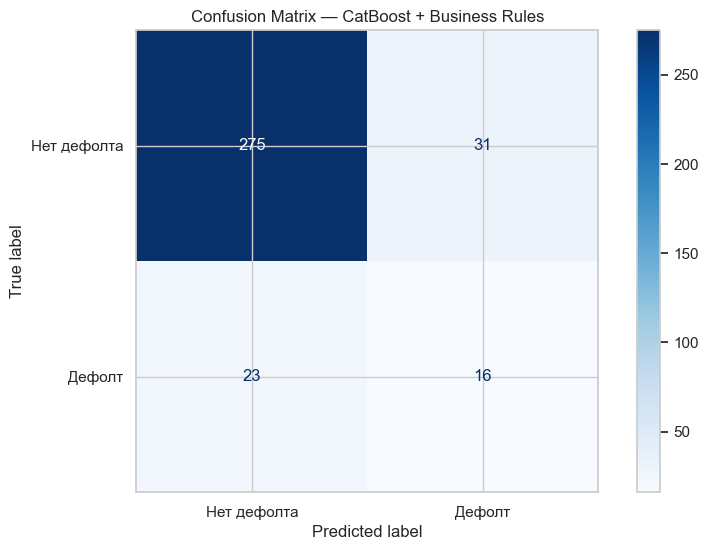

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay
cm = np.array(metrics['ConfusionMatrix'])
disp = ConfusionMatrixDisplay(cm, display_labels=['Нет дефолта', 'Дефолт'])
disp.plot(cmap='Blues', values_format='d')
plt.title(f"Confusion Matrix — {metrics['Model']}")
plt.show()

## 7. Стабильность модели

Модель стабильна во времени: PSI скор 0.028 (ниже порога 0.1).

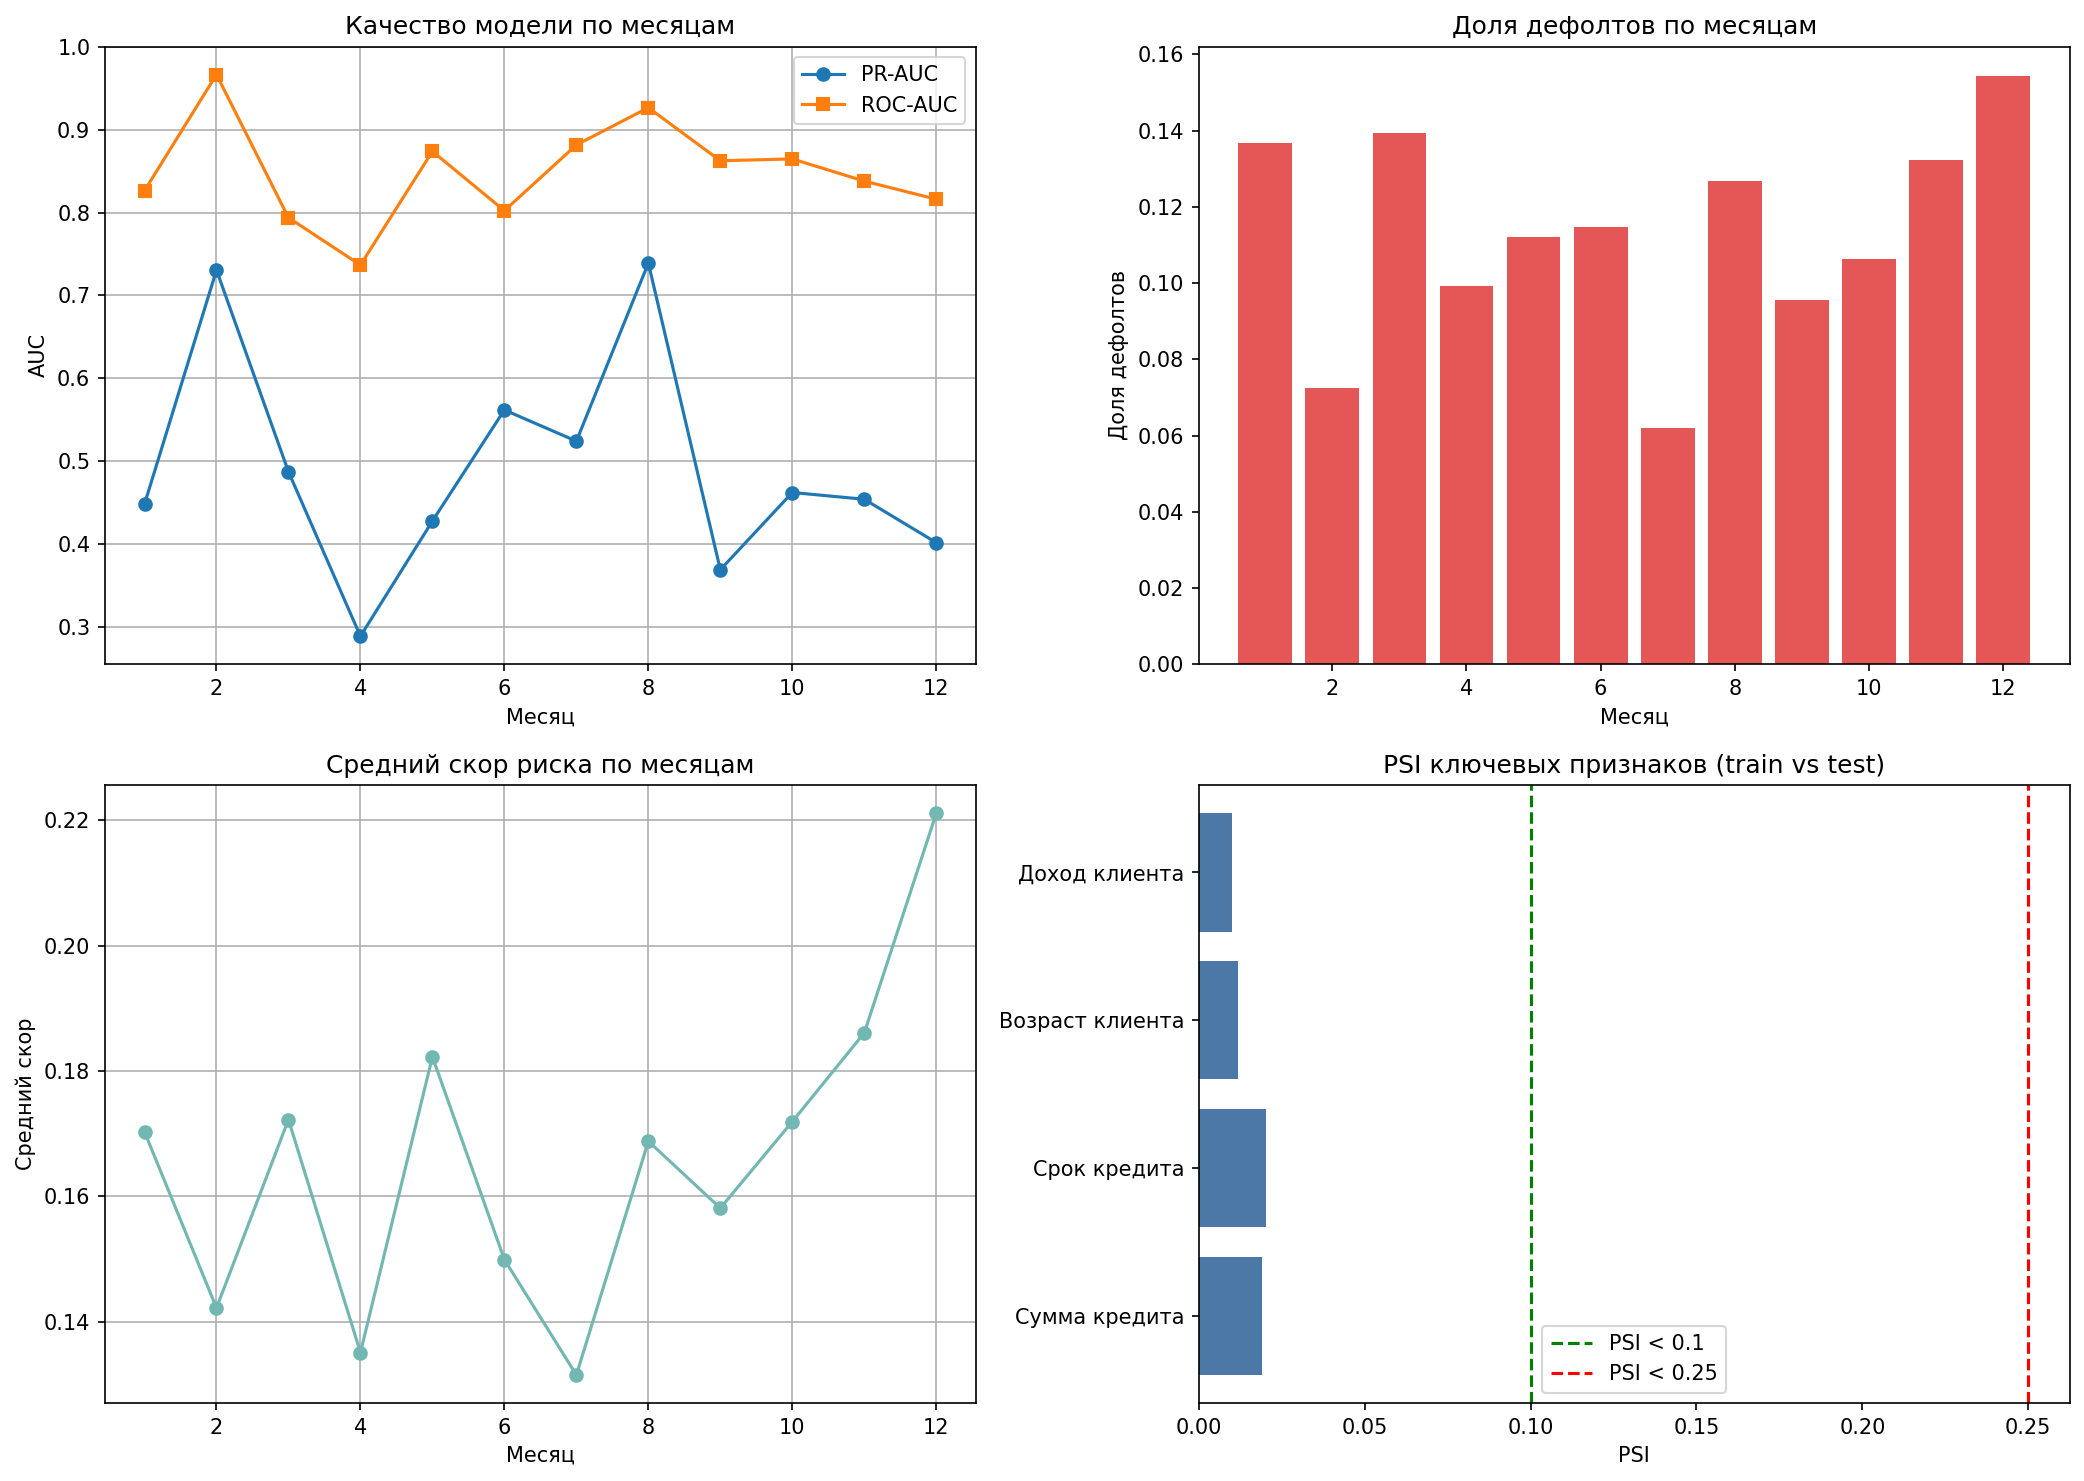

In [14]:
from IPython.display import Image
Image('artifacts/stability.png')

## 8. Интерпретация модели (SHAP)

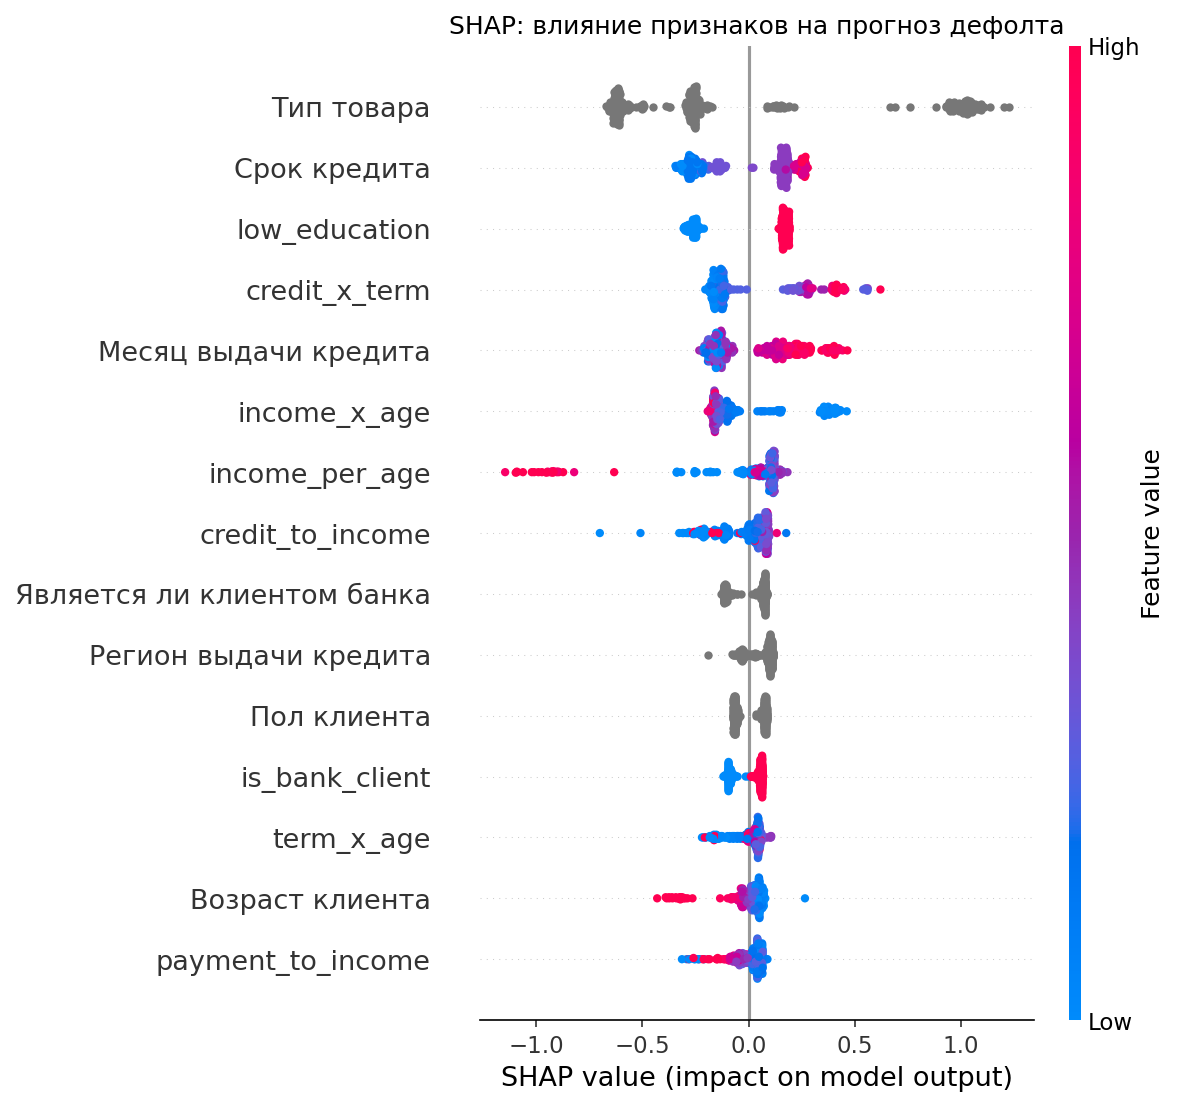

In [15]:
Image('artifacts/shap_summary.png')

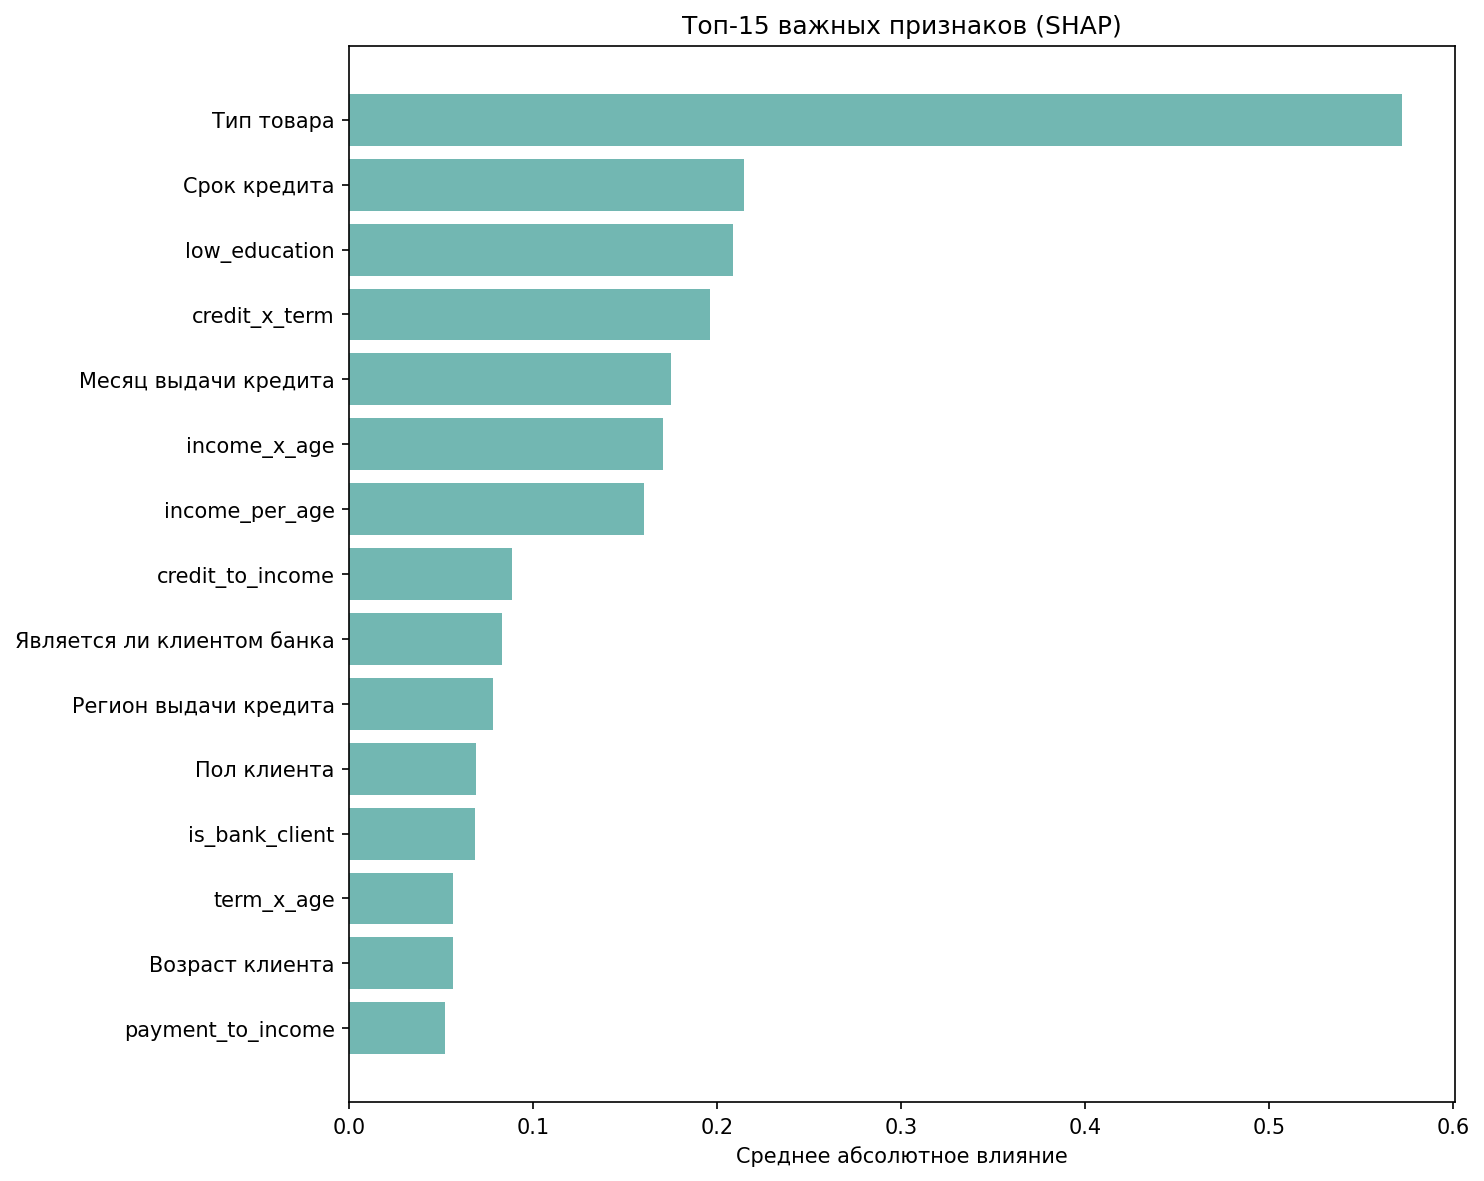

In [16]:
Image('artifacts/feature_importance.png')